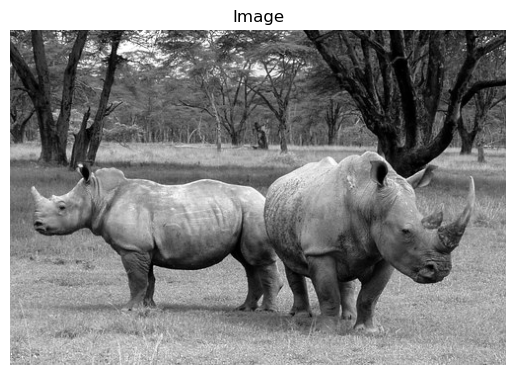

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

image = np.array(Image.open('test.jpg').convert('L')) 
plt.figure()
plt.imshow(image, cmap='gray')  
plt.axis('off')
plt.title("Image")
plt.show()

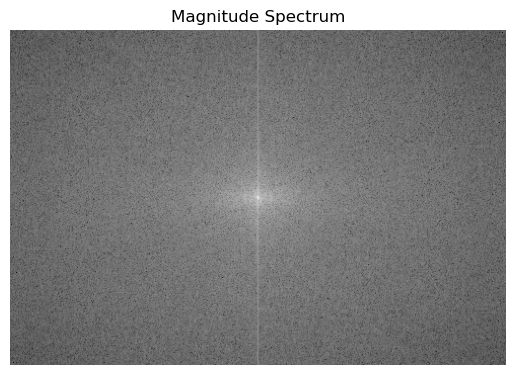

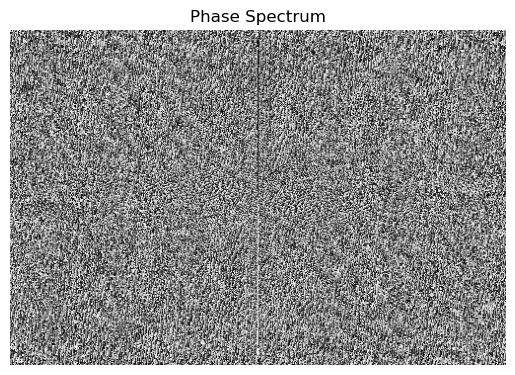

In [3]:
F = np.fft.fft2(image)
F_shifted = np.fft.fftshift(F)

magnitude = np.abs(F_shifted)
phase = np.angle(F_shifted)

plt.figure()
plt.imshow(np.log1p(magnitude), cmap='gray')  # log for visibility
plt.axis('off')
plt.title("Magnitude Spectrum")
plt.show()

plt.figure()
plt.imshow(phase, cmap='gray')
plt.axis('off')
plt.title("Phase Spectrum")
plt.show()

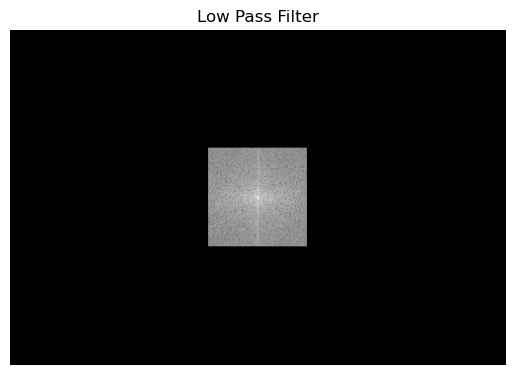

In [4]:
############### Low Pass Filter ##############
rows, cols = image.shape
crow, ccol = rows // 2 , cols // 2

# filter size
filter_size = 50  # smaller = more aggressive filtering

# Create mask with center square = 1, rest = 0 (low-pass filter)
mask = np.zeros_like(image)
mask[crow - filter_size:crow + filter_size, ccol - filter_size:ccol + filter_size] = 1

# Apply mask
F_filtered = F_shifted * mask

magnitude = np.log1p(np.abs(F_filtered))
plt.figure()
plt.imshow(magnitude, cmap = 'gray')
plt.title("Low Pass Filter")
plt.axis('off')
plt.show()

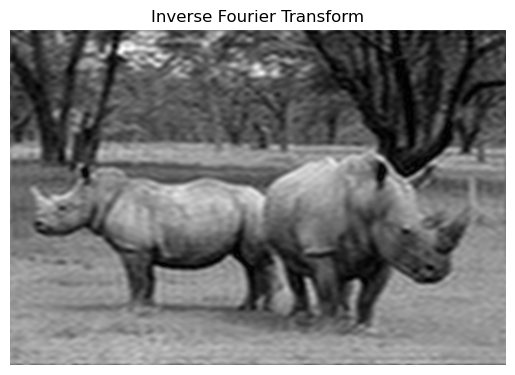

In [5]:
############### Inverse FT ##############
F_ifiltered = np.fft.ifftshift(F_filtered)
F_ifiltered = np.fft.ifft2(F_ifiltered)
magnitude = np.abs(F_ifiltered)  # take magnitude since result is complex

plt.imshow(magnitude, cmap = 'gray')
plt.title("Inverse Fourier Transform")
plt.axis('off')
plt.show()

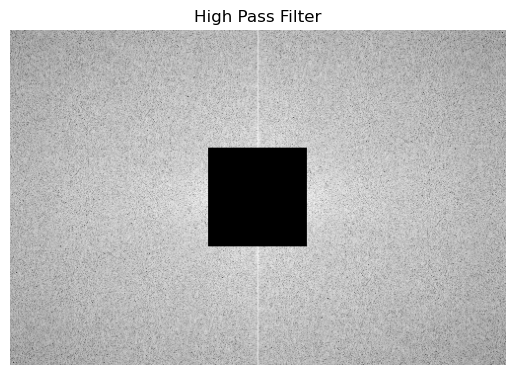

In [6]:
############### High Pass Filter ##############
rows, cols = image.shape
crow, ccol = rows // 2 , cols // 2

# filter size
filter_size = 50  # smaller = more aggressive filtering

# Create mask with center square = 1, rest = 0 (low-pass filter)
mask = 1 + np.zeros_like(image)
mask[crow - filter_size:crow + filter_size, ccol - filter_size:ccol + filter_size] = 0

# Apply mask
F_filtered = F_shifted * mask

magnitude = np.log1p(np.abs(F_filtered))
plt.figure()
plt.imshow(magnitude, cmap = 'gray')
plt.title("High Pass Filter")
plt.axis('off')
plt.show()

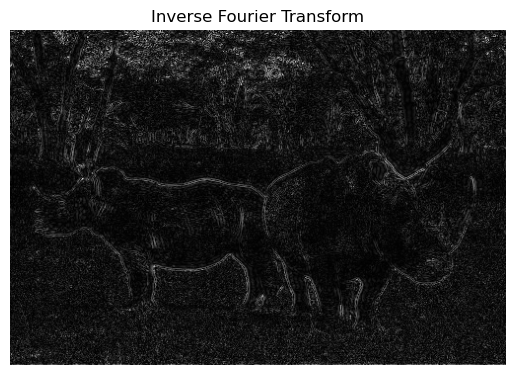

In [7]:
############### Inverse FT ##############
F_ifiltered = np.fft.ifftshift(F_filtered)
F_ifiltered = np.fft.ifft2(F_ifiltered)
magnitude = np.abs(F_ifiltered)  # take magnitude since result is complex

plt.imshow(magnitude, cmap = 'gray')
plt.title("Inverse Fourier Transform")
plt.axis('off')
plt.show()